## Import Library and Load dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib 

In [2]:
#load the dataset
file_path = r"C:\Users\mansi\Power BI\Telecom_Customer_Churn\Prediction_Dataset.xlsx"
sheet_name = 'vw_churndata'

data = pd.read_excel(file_path , sheet_name= sheet_name)

print(data.head())


  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card           65.6        593.30          0.00   
1      Credit Card          

In [3]:
data

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,43397-UTT,Female,41,No,Uttar Pradesh,6,33,NaN,Yes,Yes,...,Credit Card,74.40,896.75,0.00,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6003,22240-HAR,Male,51,Yes,Haryana,0,19,Deal 1,No,NaN,...,Credit Card,45.25,3139.80,0.00,0,0.00,3139.80,Stayed,NaN,NaN
6004,78682-KER,Female,65,Yes,Kerala,14,25,NaN,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.00,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6005,17816-ODI,Male,23,No,Odisha,2,10,NaN,Yes,Yes,...,Credit Card,70.15,4480.70,0.00,0,2107.52,6588.22,Stayed,NaN,NaN


In [4]:
list(data.columns)

['Customer_ID',
 'Gender',
 'Age',
 'Married',
 'State',
 'Number_of_Referrals',
 'Tenure_in_Months',
 'Value_Deal',
 'Phone_Service',
 'Multiple_Lines',
 'Internet_Service',
 'Internet_Type',
 'Online_Security',
 'Online_Backup',
 'Device_Protection_Plan',
 'Premium_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Streaming_Music',
 'Unlimited_Data',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Monthly_Charge',
 'Total_Charges',
 'Total_Refunds',
 'Total_Extra_Data_Charges',
 'Total_Long_Distance_Charges',
 'Total_Revenue',
 'Customer_Status',
 'Churn_Category',
 'Churn_Reason']

## Data PreProcessing

In [5]:
# checking the missing value

In [6]:
data.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3297
Phone_Service                     0
Multiple_Lines                  590
Internet_Service                  0
Internet_Type                  1223
Online_Security                1223
Online_Backup                  1223
Device_Protection_Plan         1223
Premium_Support                1223
Streaming_TV                   1223
Streaming_Movies               1223
Streaming_Music                1223
Unlimited_Data                 1223
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [7]:
missing = (data.isnull().sum() / len(data)) * 100
missing

Customer_ID                     0.000000
Gender                          0.000000
Age                             0.000000
Married                         0.000000
State                           0.000000
Number_of_Referrals             0.000000
Tenure_in_Months                0.000000
Value_Deal                     54.885966
Phone_Service                   0.000000
Multiple_Lines                  9.821874
Internet_Service                0.000000
Internet_Type                  20.359580
Online_Security                20.359580
Online_Backup                  20.359580
Device_Protection_Plan         20.359580
Premium_Support                20.359580
Streaming_TV                   20.359580
Streaming_Movies               20.359580
Streaming_Music                20.359580
Unlimited_Data                 20.359580
Contract                        0.000000
Paperless_Billing               0.000000
Payment_Method                  0.000000
Monthly_Charge                  0.000000
Total_Charges   

In [8]:
# replacing missing value
data['Churn_Category'] = data['Churn_Category'].fillna('No Churn')
data['Churn_Reason'] = data['Churn_Reason'].fillna('No Churn')

In [9]:
data['Value_Deal'] = data['Value_Deal'].fillna('No Deal')

In [10]:
data['Multiple_Lines'] = data['Multiple_Lines'].fillna('No Phone Service')

In [11]:
internet_cols = [
    'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support',
    'Streaming_TV', 'Streaming_Movies', 'Streaming_Music',
    'Unlimited_Data'
]

for col in internet_cols:
    data[col] = data[col].fillna('No Internet Service')

In [12]:
#Always cross-check:
data[data['Internet_Service'] == 'No'][internet_cols].isnull().sum()

Internet_Type             0
Online_Security           0
Online_Backup             0
Device_Protection_Plan    0
Premium_Support           0
Streaming_TV              0
Streaming_Movies          0
Streaming_Music           0
Unlimited_Data            0
dtype: int64

In [13]:
data

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,No Deal,Yes,No,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,No Churn,No Churn
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,No Deal,Yes,Yes,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,No Churn,No Churn
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,No Deal,Yes,No,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,43397-UTT,Female,41,No,Uttar Pradesh,6,33,No Deal,Yes,Yes,...,Credit Card,74.40,896.75,0.00,0,37.96,934.71,Churned,Competitor,Competitor made better offer
6003,22240-HAR,Male,51,Yes,Haryana,0,19,Deal 1,No,No Phone Service,...,Credit Card,45.25,3139.80,0.00,0,0.00,3139.80,Stayed,No Churn,No Churn
6004,78682-KER,Female,65,Yes,Kerala,14,25,No Deal,Yes,Yes,...,Bank Withdrawal,74.95,2869.85,0.00,0,599.64,3469.49,Churned,Dissatisfaction,Product dissatisfaction
6005,17816-ODI,Male,23,No,Odisha,2,10,No Deal,Yes,Yes,...,Credit Card,70.15,4480.70,0.00,0,2107.52,6588.22,Stayed,No Churn,No Churn


# Visualisation

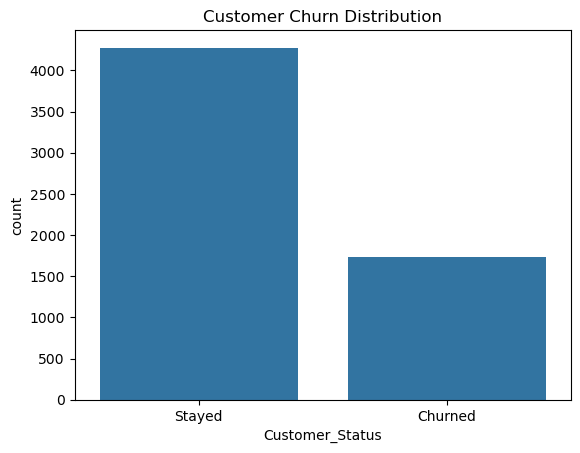

In [14]:
#Churn distribution (check imbalance)
sns.countplot(x='Customer_Status' , data = data)
plt.title('Customer Churn Distribution')
plt.show()

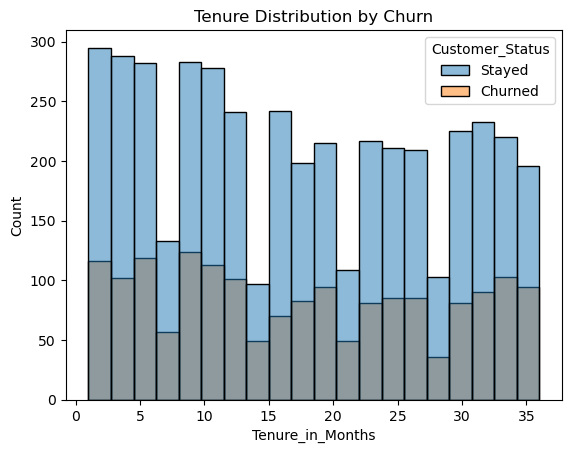

In [15]:
#Tenure vs churn ( to check if the new customer churn more)
sns.histplot(data=data, x='Tenure_in_Months', hue='Customer_Status', bins=20)
plt.title('Tenure Distribution by Churn')
plt.show()

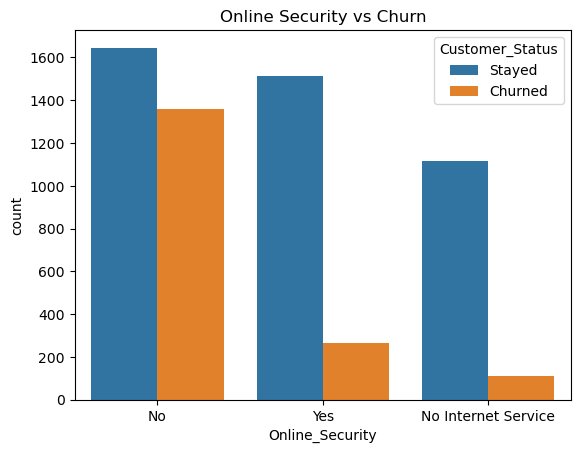

In [16]:
sns.countplot(x='Online_Security', hue='Customer_Status', data=data)
plt.title('Online Security vs Churn')
plt.show()

In [17]:
# drop column that wont be used for predication
data = data.drop(['Customer_ID', 'Churn_Category' , 'Churn_Reason'] , axis =1)

In [18]:
data['Customer_Status'].value_counts(dropna=False)

Customer_Status
Stayed     4275
Churned    1732
Name: count, dtype: int64

## Training the Model

In [19]:
# Map target
data['Customer_Status'] = data['Customer_Status'].map({
    'Stayed': 0,
    'Churned': 1
})

# Split
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Encode features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train model
rf_model = RandomForestClassifier(n_estimators= 100 , random_state= 42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# evaluate model
y_pred = rf_model.predict(X_test)

print("Confusion Matrix: ")
print(confusion_matrix(y_test , y_pred))

print("\nClassification Report:")
print(classification_report(y_test , y_pred))

#Feature Selection
importance = rf_model.feature_importances_
indices = np.argsort(importance)[::-1]



Confusion Matrix: 
[[993  61]
 [176 272]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1054
           1       0.82      0.61      0.70       448

    accuracy                           0.84      1502
   macro avg       0.83      0.77      0.79      1502
weighted avg       0.84      0.84      0.83      1502



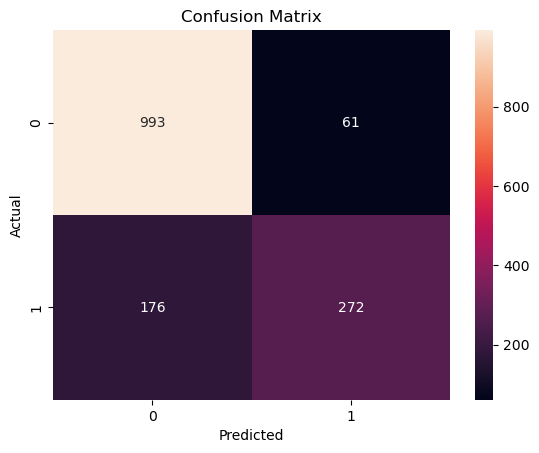

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1054
           1       0.82      0.61      0.70       448

    accuracy                           0.84      1502
   macro avg       0.83      0.77      0.79      1502
weighted avg       0.84      0.84      0.83      1502



In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

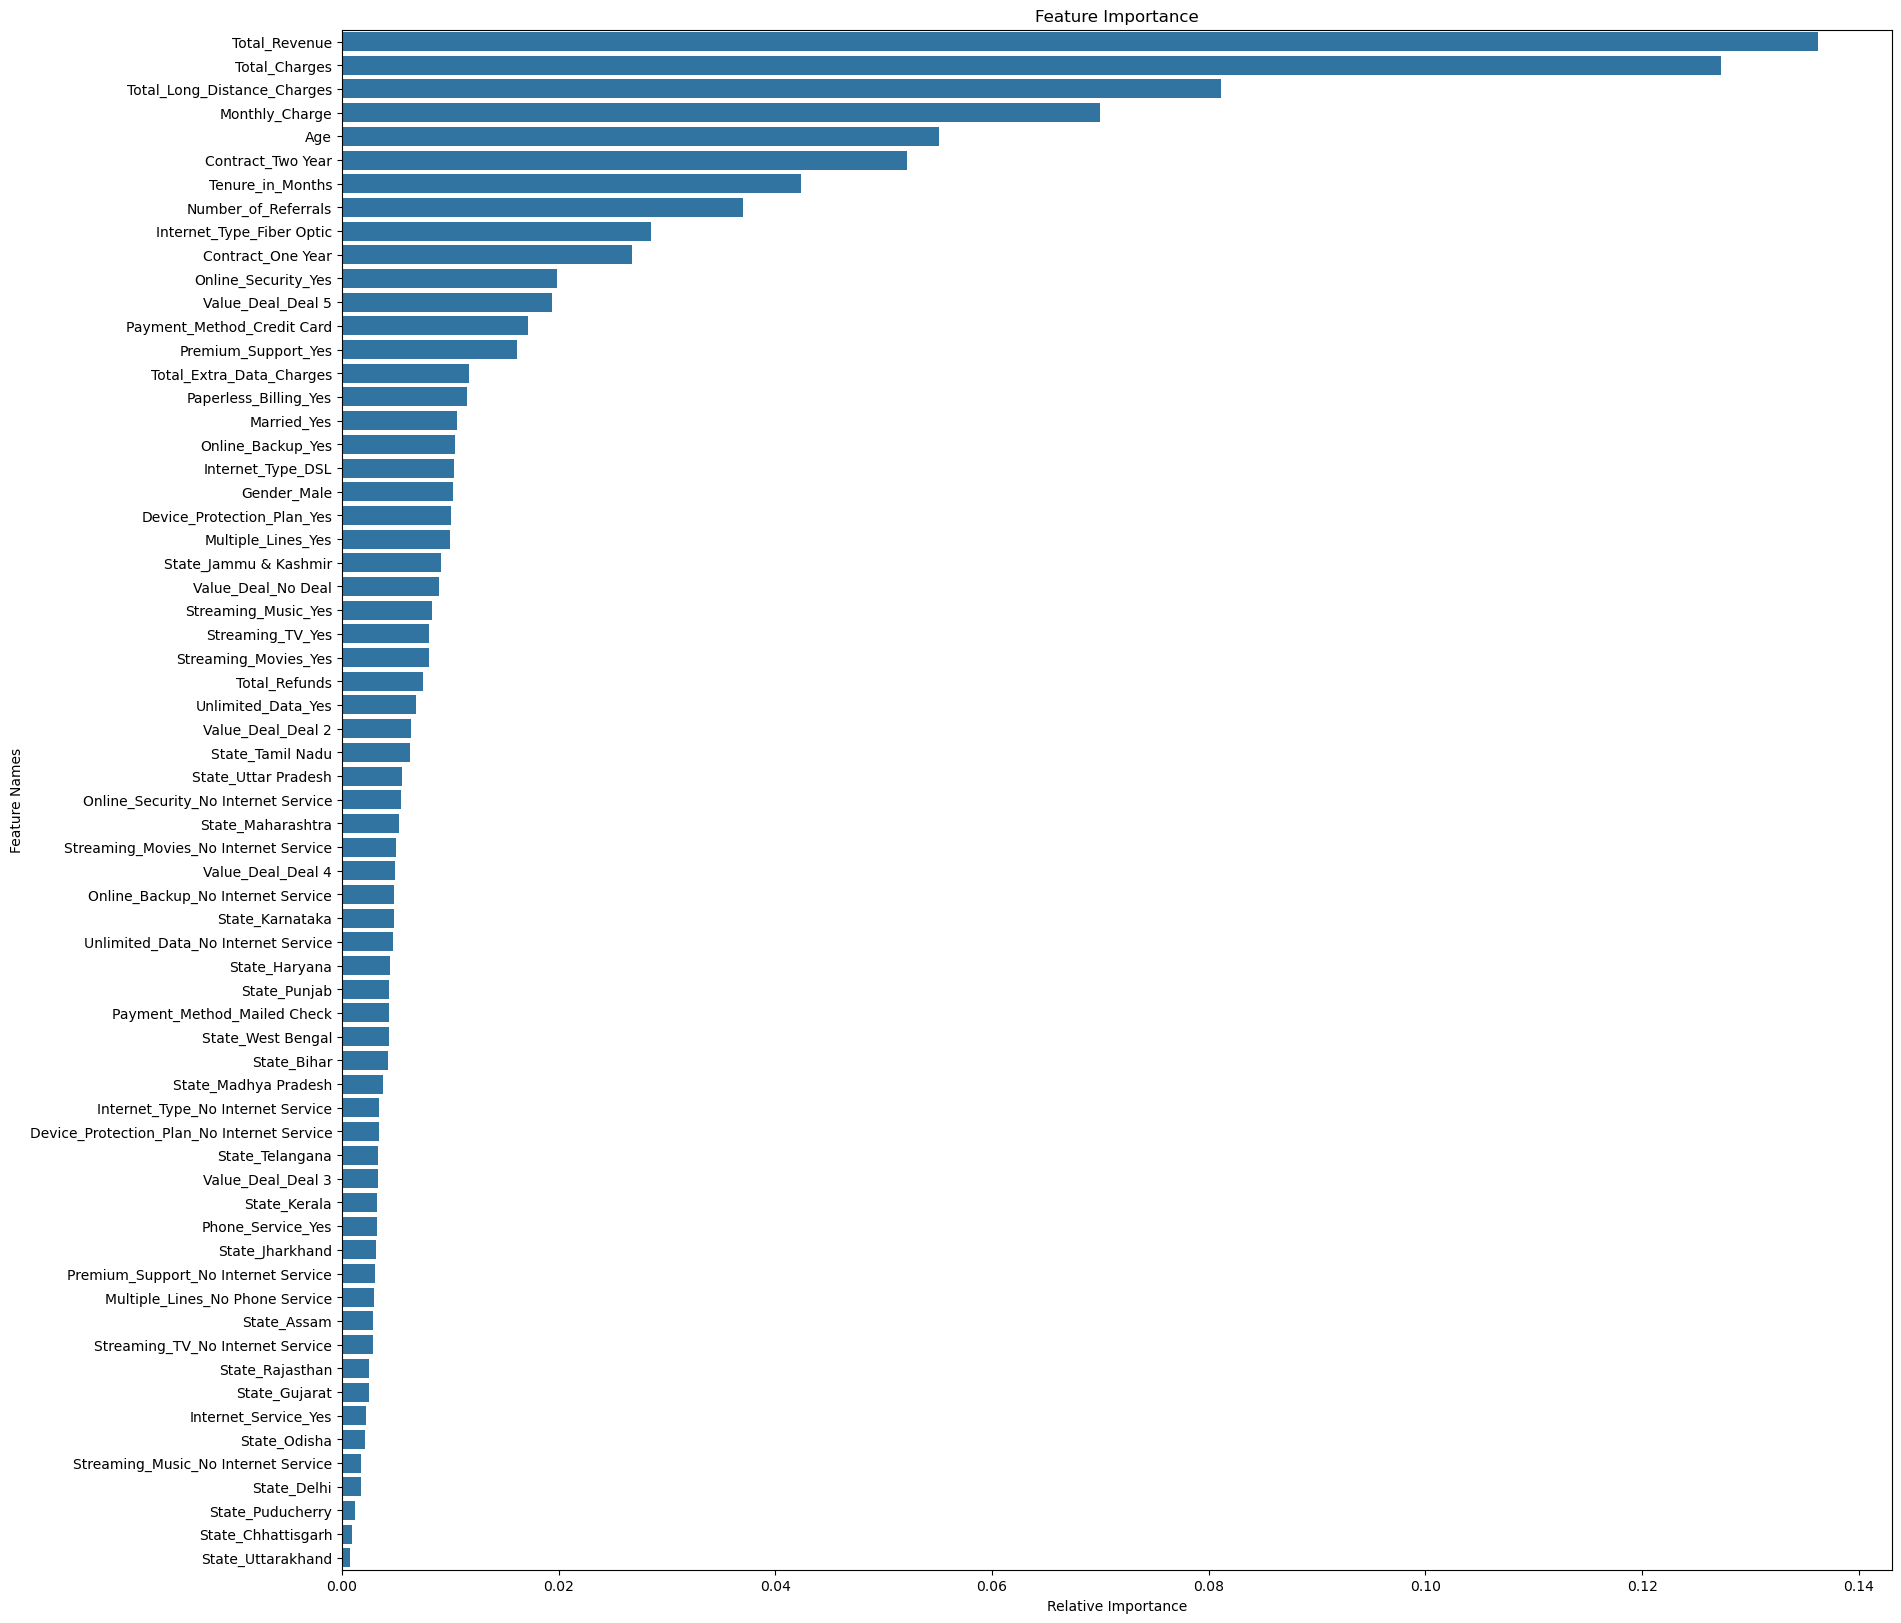

In [22]:
#Plot the feature importance 
plt.figure(figsize=(20,20)) 
sns.barplot(x=importance[indices], y = X.columns[indices]) 
plt.title('Feature Importance') 
plt.xlabel('Relative Importance') 
plt.ylabel('Feature Names') 
plt.show()

# Predict on new Data

In [23]:
#load the dataset
file_path = r"C:\Users\mansi\Power BI\Telecom_Customer_Churn\Prediction_Dataset.xlsx"
sheet_name = 'vw_joindata'

df = pd.read_excel(file_path , sheet_name= sheet_name)

print(df.head())


  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal          72.10          72.1           0.0   
1      Cre

In [24]:
df

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,Bank Withdrawal,72.10,72.10,0.0,0,7.77,79.87,Joined,NaN,NaN
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,Credit Card,19.85,57.20,0.0,0,9.36,66.56,Joined,NaN,NaN
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,Credit Card,44.30,44.30,0.0,0,42.95,87.25,Joined,NaN,NaN
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,Credit Card,19.95,58.00,0.0,0,8.07,66.07,Joined,NaN,NaN
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,Credit Card,20.05,33.70,0.0,0,3.62,37.32,Joined,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,31412-HAR,Female,81,Yes,Haryana,14,29,NaN,Yes,No,...,Bank Withdrawal,19.20,37.20,0.0,0,14.06,51.26,Joined,NaN,NaN
407,54997-UTT,Female,55,No,Uttar Pradesh,7,23,NaN,Yes,No,...,Credit Card,44.00,44.00,0.0,0,26.15,70.15,Joined,NaN,NaN
408,56728-RAJ,Male,40,No,Rajasthan,0,1,NaN,Yes,No,...,Credit Card,45.60,45.60,0.0,0,37.44,83.04,Joined,NaN,NaN
409,47624-TAM,Female,62,Yes,Tamil Nadu,7,29,NaN,Yes,No,...,Mailed Check,-5.00,189.10,0.0,0,100.59,289.69,Joined,NaN,NaN


In [25]:
df.isnull().sum()

Customer_ID                      0
Gender                           0
Age                              0
Married                          0
State                            0
Number_of_Referrals              0
Tenure_in_Months                 0
Value_Deal                     251
Phone_Service                    0
Multiple_Lines                  32
Internet_Service                 0
Internet_Type                  167
Online_Security                167
Online_Backup                  167
Device_Protection_Plan         167
Premium_Support                167
Streaming_TV                   167
Streaming_Movies               167
Streaming_Music                167
Unlimited_Data                 167
Contract                         0
Paperless_Billing                0
Payment_Method                   0
Monthly_Charge                   0
Total_Charges                    0
Total_Refunds                    0
Total_Extra_Data_Charges         0
Total_Long_Distance_Charges      0
Total_Revenue       

In [26]:
missing_df = (df.isnull().sum() / len(data)) * 100
missing_df

Customer_ID                    0.000000
Gender                         0.000000
Age                            0.000000
Married                        0.000000
State                          0.000000
Number_of_Referrals            0.000000
Tenure_in_Months               0.000000
Value_Deal                     4.178458
Phone_Service                  0.000000
Multiple_Lines                 0.532712
Internet_Service               0.000000
Internet_Type                  2.780090
Online_Security                2.780090
Online_Backup                  2.780090
Device_Protection_Plan         2.780090
Premium_Support                2.780090
Streaming_TV                   2.780090
Streaming_Movies               2.780090
Streaming_Music                2.780090
Unlimited_Data                 2.780090
Contract                       0.000000
Paperless_Billing              0.000000
Payment_Method                 0.000000
Monthly_Charge                 0.000000
Total_Charges                  0.000000


In [27]:
# handling the missing value 

df['Churn_Category'] = df['Churn_Category'].fillna('No Churn')
df['Churn_Reason'] = df['Churn_Reason'].fillna('No Churn')

In [28]:
df['Value_Deal'] = df['Value_Deal'].fillna('No Deal')
df['Multiple_Lines'] = df['Multiple_Lines'].fillna('No Phone Service')
internet_cols = [
    'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support',
    'Streaming_TV', 'Streaming_Movies', 'Streaming_Music',
    'Unlimited_Data'
]

for col in internet_cols:
    df[col] = data[col].fillna('No Internet Service')
    

In [29]:
#Always cross-check:
df[df['Internet_Service'] == 'No'][internet_cols].isnull().sum()

Internet_Type             0
Online_Security           0
Online_Backup             0
Device_Protection_Plan    0
Premium_Support           0
Streaming_TV              0
Streaming_Movies          0
Streaming_Music           0
Unlimited_Data            0
dtype: int64

In [35]:
# Retain the original DataFrame to preserve unencoded columns
original_data = df.copy()


# Retain the Customer_ID column
customer_ids = df['Customer_ID'] 

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = df.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

 

# OneHotEncoding
new_data = pd.get_dummies(new_data)
# VERY IMPORTANT: align with training data
new_data = new_data.reindex(columns=X.columns, fill_value=0)

 
# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]


#Save the results

original_data.to_csv(r"C:\Users\mansi\Power BI\Telecom_Customer_Churn\Predictions.csv", index=False)